In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.math import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Dense, DepthwiseConv2D, Reshape, Multiply
import keras_tuner as kt
import os
import random
import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Define hyperparameters
hyperparameters = {
    'learning_rate': 0.001,
    'batch_size': 8,
    'epochs': 50,
    'optimizer': 'adam',
    'loss_function': 'sparse_categorical_crossentropy',
    'image_size': (128, 128),
    'num_classes': 4,
    'data_augmentation': True,
}

# TensorBoard Logging
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# Create the TensorBoard callback
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq='epoch',
)


In [3]:
# --- UPDATED PATHS ---
train_csv_path = "C:/Users/matko/Desktop/data_h_c_s_a/spectograms/train.csv"
train_img_dir = "C:/Users/matko/Desktop/data_h_c_s_a/spectograms/train"

# Load the dataset
train = pd.read_csv(train_csv_path)

# Split into train and validation sets
train, valid = train_test_split(
    train,
    test_size=0.2,         # 20% for validation
    stratify=train["category"],  # keep class distribution
    random_state=42
)

Train shape: (36128, 2)
Valid shape: (9032, 2)


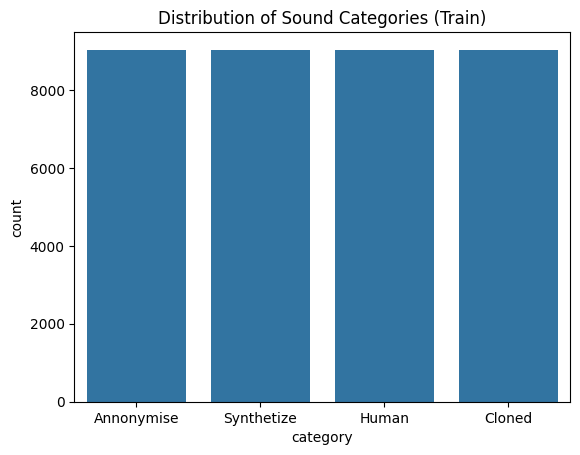

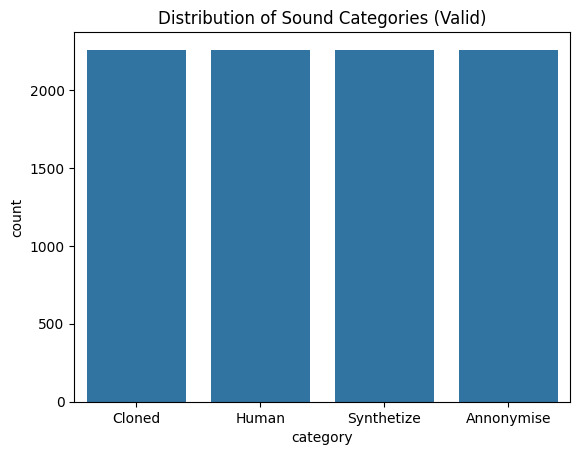

In [4]:
# Check the shape of the dataset
print("Train shape:", train.shape)
print("Valid shape:", valid.shape)

# Plot the distribution of ship categories
ship_categories = {0: 'Synthetize', 1: 'Annonymise', 2: 'Cloned', 3: 'Human'}
sns.countplot(x=train["category"].map(ship_categories))
plt.title("Distribution of Sound Categories (Train)")
plt.show()

sns.countplot(x=valid["category"].map(ship_categories))
plt.title("Distribution of Sound Categories (Valid)")
plt.show()

In [5]:
def load_and_preprocess_images(df, img_dir):
    images = []
    for img_name in df["image"]:  # Use the correct column name for image filenames
        img_path = os.path.join(img_dir, img_name)
        img = tf.keras.utils.load_img(img_path, color_mode='grayscale')  # No target_size needed
        imgarr = tf.keras.utils.img_to_array(img) / 255.0
        images.append(imgarr)
    return np.asarray(images)

# Prepare data
X_train = load_and_preprocess_images(train, train_img_dir)
X_valid = load_and_preprocess_images(valid, train_img_dir)



In [6]:
def swish(x):
    return x * tf.nn.sigmoid(x)

def mb_conv_block(x, filters_in, filters_out, expand_ratio=1, stride=1, se_ratio=0.25):
    inputs = x  # Save for residual connection
    channels = filters_in * expand_ratio
    if expand_ratio != 1:
        x = Conv2D(channels, 1, padding='same', use_bias=False)(x)
        x = BatchNormalization()(x)
        x = Activation(swish)(x)
    
    x = DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation(swish)(x)
    
    if se_ratio:
        se_channels = max(1, int(filters_in * se_ratio))
        se = GlobalAveragePooling2D()(x)
        se = Reshape((1, 1, channels))(se)
        se = Conv2D(se_channels, 1, padding='same', activation='relu')(se)
        se = Conv2D(channels, 1, padding='same', activation='sigmoid')(se)
        x = Multiply()([x, se])
    
    x = Conv2D(filters_out, 1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    
    if stride == 1 and filters_in == filters_out:
        x = Add()([x, inputs])
    
    return x

def build_lite_efficientnet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    
    # Stem
    x = Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation(swish)(x)
    
    # MBConv blocks (scaled down version)
    blocks = [
        # expand, in_ch, out_ch, stride, se_ratio, repeats
        (1, 16, 16, 1, 0.25, 1),
        (6, 16, 24, 2, 0.25, 2),
        (6, 24, 40, 2, 0.25, 2),
        (6, 40, 80, 2, 0.25, 3),
        (6, 80, 112, 1, 0.25, 3),
        (6, 112, 192, 2, 0.25, 4),
        (6, 192, 320, 1, 0.25, 1)
    ]
    
    for expand, in_ch, out_ch, stride, se_ratio, repeats in blocks:
        for i in range(repeats):
            if i > 0:  # Only first block in sequence uses stride
                stride = 1
            x = mb_conv_block(
                x, 
                filters_in=in_ch, 
                filters_out=out_ch,
                expand_ratio=expand,
                stride=stride,
                se_ratio=se_ratio
            )
            in_ch = out_ch  # Update input channels for next block
    
    # Head
    x = Conv2D(640, 1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation(swish)(x)
    x = GlobalAveragePooling2D()(x)
    
    # Output
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs)

In [7]:
# Extract labels
y_train = train["category"].values
y_valid = valid["category"].values

In [8]:
# EarlyStopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

In [9]:
# Define tuner directory for Keras Tuner results
tuner_dir = "tuner_dir"

def build_tunable_lite_efficientnet(hp):
    input_shape = (*hyperparameters['image_size'], 1)
    num_classes = hyperparameters['num_classes']

    inputs = Input(shape=input_shape)
    x = Conv2D(
        hp.Int('stem_filters', min_value=8, max_value=32, step=8),
        3, strides=2, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation(swish)(x)

    # Use a single tunable MBConv block for demonstration (expand as needed)
    expand = hp.Choice('expand_ratio', [1, 3, 6])
    in_ch = hp.Int('in_ch', 8, 32, step=8)
    out_ch = hp.Int('out_ch', 16, 48, step=8)
    stride = 1
    se_ratio = 0.25

    x = mb_conv_block(
        x,
        filters_in=in_ch,
        filters_out=out_ch,
        expand_ratio=expand,
        stride=stride,
        se_ratio=se_ratio
    )

    x = Conv2D(
        hp.Int('head_filters', min_value=64, max_value=256, step=64),
        1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation(swish)(x)
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)

    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=hyperparameters['loss_function'],
        metrics=['accuracy']
    )
    return model

tuner = kt.Hyperband(
    build_tunable_lite_efficientnet,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory=tuner_dir,
    project_name='lite_effnet_tuning'
)

stop_early = EarlyStopping(monitor='val_loss', patience=3)

Reloading Tuner from tuner_dir\lite_effnet_tuning\tuner0.json


In [14]:
tuner.search(
    X_train, y_train,
    epochs=10,
    validation_data=(X_valid, y_valid),
    callbacks=[stop_early]
)

Trial 23 Complete [00h 06m 38s]
val_accuracy: 0.8631532192230225

Best val_accuracy So Far: 0.8631532192230225
Total elapsed time: 00h 57m 02s


In [10]:
# Get the best model and retrain
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=hyperparameters['batch_size'],
    epochs=hyperparameters['epochs'],
    callbacks=[tensorboard_callback, early_stopping]
)

# Save the best model
best_model.save('best_lite_effnet_tuned.h5.keras')

Epoch 1/50
4516/4516 [==============================] - 88s 10ms/step - loss: 0.2071 - accuracy: 0.9406 - val_loss: 2.0615 - val_accuracy: 0.6209
Epoch 2/50
4516/4516 [==============================] - 47s 10ms/step - loss: 0.0514 - accuracy: 0.9852 - val_loss: 4.1468 - val_accuracy: 0.5153
Epoch 3/50
4516/4516 [==============================] - 47s 10ms/step - loss: 0.0334 - accuracy: 0.9904 - val_loss: 0.4710 - val_accuracy: 0.8200
Epoch 4/50
4516/4516 [==============================] - 62s 14ms/step - loss: 0.0278 - accuracy: 0.9918 - val_loss: 2.0381 - val_accuracy: 0.5870
Epoch 5/50
4516/4516 [==============================] - 66s 15ms/step - loss: 0.0235 - accuracy: 0.9932 - val_loss: 3.0784 - val_accuracy: 0.5614
Epoch 6/50
4516/4516 [==============================] - 66s 15ms/step - loss: 0.0196 - accuracy: 0.9944 - val_loss: 0.7718 - val_accuracy: 0.7992
Epoch 7/50
4516/4516 [==============================] - 64s 14ms/step - loss: 0.0142 - accuracy: 0.9956 - val_loss: 2.6359 -

In [13]:
# Build model
model = build_lite_efficientnet(
    input_shape=(*hyperparameters['image_size'], 1),
    num_classes=hyperparameters['num_classes']
)

model.compile(
    optimizer=hyperparameters['optimizer'],
    loss=hyperparameters['loss_function'],
    metrics=['accuracy']
)

model.summary()

# Update checkpoint name
checkpoint = ModelCheckpoint('best_lite_effnet.h5.keras', 
                            monitor='val_accuracy', 
                            save_best_only=True, 
                            mode='max', 
                            verbose=1)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_5 (Conv2D)              (None, 64, 64, 16)   144         ['input_3[0][0]']                
                                                                                                  
 batch_normalization_4 (BatchNo  (None, 64, 64, 16)  64          ['conv2d_5[0][0]']               
 rmalization)                                                                                     
                                                                                              

In [14]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=hyperparameters['batch_size'],
    epochs=hyperparameters['epochs'],
    callbacks=[checkpoint, tensorboard_callback, early_stopping]
)

Epoch 1/50
4515/4516 [============================>.] - ETA: 0s - loss: 0.3790 - accuracy: 0.8212
Epoch 1: val_accuracy improved from -inf to 0.76982, saving model to best_lite_effnet.h5.keras
4516/4516 [==============================] - 148s 30ms/step - loss: 0.3789 - accuracy: 0.8213 - val_loss: 0.7373 - val_accuracy: 0.7698
Epoch 2/50
4515/4516 [============================>.] - ETA: 0s - loss: 0.2483 - accuracy: 0.8625
Epoch 2: val_accuracy improved from 0.76982 to 0.85241, saving model to best_lite_effnet.h5.keras
4516/4516 [==============================] - 121s 27ms/step - loss: 0.2483 - accuracy: 0.8625 - val_loss: 0.2797 - val_accuracy: 0.8524
Epoch 3/50
4515/4516 [============================>.] - ETA: 0s - loss: 0.2176 - accuracy: 0.8735
Epoch 3: val_accuracy did not improve from 0.85241
4516/4516 [==============================] - 120s 26ms/step - loss: 0.2176 - accuracy: 0.8735 - val_loss: 0.4364 - val_accuracy: 0.8428
Epoch 4/50
4514/4516 [============================>.] 

283/283 - 3s - loss: 2.2318e-04 - accuracy: 0.9999 - 3s/epoch - 11ms/step

Lite EfficientNet Validation Accuracy: 0.9998892545700073
283/283 [==============================] - 3s 10ms/step


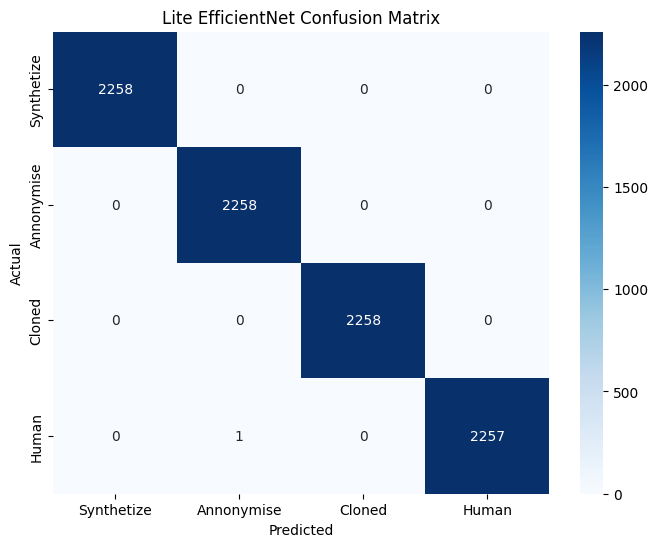

In [11]:
# Load the best model
best_model = models.load_model('best_lite_effnet_tuned.h5.keras')

# Evaluate the model
val_loss, best_val_acc = best_model.evaluate(X_valid, y_valid, verbose=2)
print("\nLite EfficientNet Validation Accuracy:", best_val_acc)

# Generate predictions
val_predictions = best_model.predict(X_valid)
val_predicted_classes = np.argmax(val_predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(y_valid, val_predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=ship_categories.values(), 
            yticklabels=ship_categories.values())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Lite EfficientNet Confusion Matrix')
plt.show()

43/43 [==============================] - 0s 11ms/step
Test accuracy: 0.9993


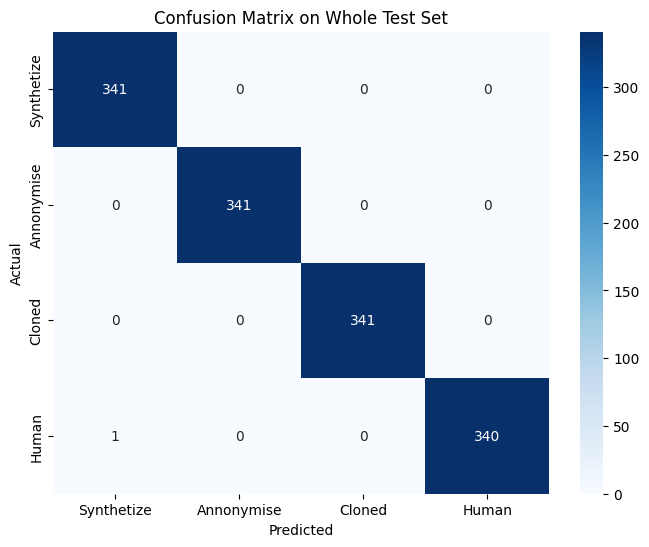

In [12]:
# Path to test images and labels
test_img_dir = "C:/Users/matko/Desktop/data_h_c_s_a/train_v3/test"
test_csv_path = "C:/Users/matko/Desktop/data_h_c_s_a/train_v3/test.csv"

# Load test image names and labels
test_img_names = os.listdir(test_img_dir)
test_df = pd.read_csv(test_csv_path)
test_df["Actual Class Index"] = test_df["category"] - 1  # zero-based

# Load and preprocess ALL test images
all_test_images = []
for img_name in test_img_names:
    img_path = os.path.join(test_img_dir, img_name)
    img = tf.keras.utils.load_img(img_path, target_size=hyperparameters['image_size'], color_mode='grayscale')
    imgarr = tf.keras.utils.img_to_array(img) / 255.0
    all_test_images.append(imgarr)
all_test_images = np.asarray(all_test_images)

# Predict classes for all test images
all_test_preds = best_model.predict(all_test_images)
all_test_pred_classes = np.argmax(all_test_preds, axis=1)

# Prepare actual class indices in the same order as test_img_names
actual_class_map = dict(zip(test_df["image"], test_df["Actual Class Index"]))
all_actual_class_indices = [actual_class_map[img] for img in test_img_names]

# Calculate test accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
test_accuracy = accuracy_score(all_actual_class_indices, all_test_pred_classes)
print(f"Test accuracy: {test_accuracy:.4f}")

# Plot confusion matrix for the whole test set
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_actual_class_indices, all_test_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=ship_categories.values(), 
            yticklabels=ship_categories.values())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on Whole Test Set')
plt.show()